In [33]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

print("Libraries imported successfully!")

Libraries imported successfully!


In [34]:
import pandas as pd

df = pd.read_csv("Nassau Candy Distributor.csv")
print(df.head())

   Row ID                      Order ID  Order Date   Ship Date  \
0       1  US-2021-103800-CHO-MIL-31000  03-01-2024  30-06-2026   
1       2  US-2021-112326-CHO-TRI-54000  04-01-2024  01-07-2026   
2       3  US-2021-112326-CHO-NUT-13000  04-01-2024  01-07-2026   
3       4  US-2021-112326-CHO-SCR-58000  04-01-2024  01-07-2026   
4       5  US-2021-141817-CHO-TRI-54000  05-01-2024  05-07-2026   

        Ship Mode  Customer ID Country/Region          City State/Province  \
0  Standard Class       103800  United States       Houston          Texas   
1  Standard Class       112326  United States    Naperville       Illinois   
2  Standard Class       112326  United States    Naperville       Illinois   
3  Standard Class       112326  United States    Naperville       Illinois   
4  Standard Class       141817  United States  Philadelphia   Pennsylvania   

  Postal Code   Division    Region     Product ID  \
0       77095  Chocolate  Interior  CHO-MIL-31000   
1       60540  Chocola

             Row ID    Customer ID         Sales         Units  Gross Profit  \
count  10194.000000   10194.000000  10194.000000  10194.000000  10194.000000   
mean    5097.500000  134468.961154     13.908537      3.791838      9.166451   
std     2942.898656   20231.483007     11.341020      2.228317      6.643740   
min        1.000000  100006.000000      1.250000      1.000000      0.250000   
25%     2549.250000  117212.000000      7.200000      2.000000      4.900000   
50%     5097.500000  133550.000000     10.800000      3.000000      7.470000   
75%     7645.750000  152051.000000     18.000000      5.000000     12.250000   
max    10194.000000  192314.000000    260.000000     14.000000    130.000000   

               Cost  
count  10194.000000  
mean       4.742087  
std        5.061647  
min        0.600000  
25%        2.400000  
50%        3.600000  
75%        5.700000  
max      130.000000  


<Axes: >

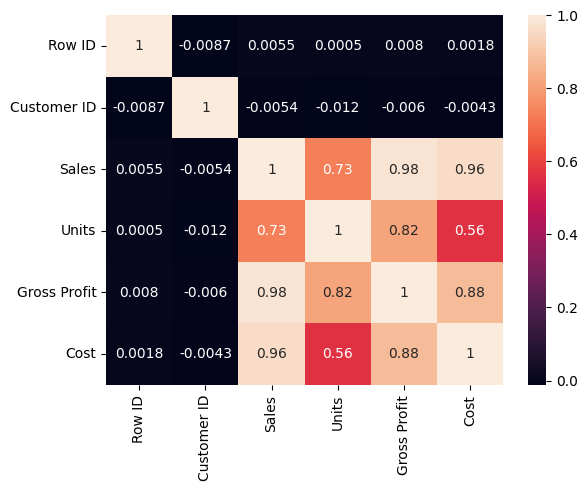

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Nassau Candy Distributor.csv")
print(df.describe())
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Feature Engineering: Creating a Profit Margin feature
# We use .fillna(0) just in case there are any divisions by zero
df['Profit_Margin'] = (df['Gross Profit'] / df['Sales']).fillna(0)

# 2. Selecting actual columns for Clustering
# Let's cluster based on Sales, Units, and our new Profit_Margin
features = ['Sales', 'Units', 'Profit_Margin']
x = df[features]

# 3. Scaling the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(x)

# 4. Applying KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_data)

print("Feature Engineering and Clustering complete!")
print(df[['Sales', 'Profit_Margin', 'Cluster']].head())

Feature Engineering and Clustering complete!
   Sales  Profit_Margin  Cluster
0   6.50       0.649231        0
1   7.50       0.653333        0
2  10.47       0.713467        0
3  10.80       0.694444        0
4  11.25       0.653333        0


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 1. Prepare Data
# We use the features we engineered to predict the 'Cluster'
X = df[['Sales', 'Units', 'Profit_Margin']]
y = df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier()
}

# 3. Train and Evaluate
print("Model Accuracy Results:")
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.fit(X_train, y_train).predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"{name}: {accuracy:.2%}")

Model Accuracy Results:
Logistic Regression: 99.75%
Random Forest: 100.00%
XGBoost: 100.00%


In [38]:
import numpy as np

# 1. Create a copy of the data for simulation
sim_df = df.copy()

# 2. Scenario: What if we increase 'Sales' (Price) by 10%?
price_increase = 1.10
sim_df['Sales'] = sim_df['Sales'] * price_increase

# 3. Recalculate Profit Margin based on the new Sales price
# (Assuming Cost stays the same)
sim_df['Gross Profit'] = sim_df['Sales'] - sim_df['Cost']
sim_df['Profit_Margin'] = (sim_df['Gross Profit'] / sim_df['Sales']).fillna(0)

# 4. Predict how this changes our Clusters using the trained Random Forest model
# We use the model from Step 3 (assuming it's named 'model' or from our loop)
rf_model = models["Random Forest"]
X_sim = sim_df[['Sales', 'Units', 'Profit_Margin']]
sim_df['New_Cluster'] = rf_model.predict(X_sim)

# 5. Compare Results
print("--- Simulation Results (10% Price Increase) ---")
print(f"Original Avg Profit: ${df['Gross Profit'].mean():.2f}")
print(f"Simulated Avg Profit: ${sim_df['Gross Profit'].mean():.2f}")

# Check if any customers shifted clusters
shifts = (df['Cluster'] != sim_df['New_Cluster']).sum()
print(f"Number of transactions that shifted clusters: {shifts}")

--- Simulation Results (10% Price Increase) ---
Original Avg Profit: $9.17
Simulated Avg Profit: $10.56
Number of transactions that shifted clusters: 0


In [39]:
def get_recommendations(customer_id, df, top_n=3):
    # 1. Find the cluster of the given customer
    cust_cluster = df[df['Customer ID'] == customer_id]['Cluster'].iloc[0]

    # 2. Get all transactions from that same cluster
    cluster_data = df[df['Cluster'] == cust_cluster]

    # 3. Find the most popular items in this cluster (by Units sold)
    # Note: Replace 'Row ID' with 'Product ID' or 'Product Name' if your CSV has those columns!
    recommendations = cluster_data.groupby('Row ID')['Units'].sum().sort_values(ascending=False)

    return recommendations.head(top_n)

# Test it with a random Customer ID from your data
sample_cust = df['Customer ID'].iloc[0]
print(f"Top Recommendations for Customer {sample_cust}:")
print(get_recommendations(sample_cust, df))

Top Recommendations for Customer 103800:
Row ID
9378    5
9295    5
8283    5
Name: Units, dtype: int64


In [40]:

df.to_csv('Nassau_Candy_Analysis_Results.csv', index=False)
print("✓ File saved as 'Nassau_Candy_Analysis_Results.csv'")

✓ File saved as 'Nassau_Candy_Analysis_Results.csv'


In [41]:
%%writefile nassau_candy_app.py
"""
Nassau Candy Distributor – Factory Optimization Dashboard
==========================================================
Fully rebuilt for Google Colab + Streamlit compatibility.
Run: streamlit run nassau_candy_app.py --server.port=8501
"""

# ── Imports ───────────────────────────────────────────────
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")          # Non-interactive backend — required in Colab
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from math import radians, cos, sin, asin, sqrt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Page config ───────────────────────────────────────────
st.set_page_config(
    page_title="Nassau Candy – Factory Optimizer",
    page_icon="🍬",
    layout="wide",
)

# ── Styling ───────────────────────────────────────────────
st.markdown("""
<style>
.big-title  { font-size:2rem; font-weight:700; color:#e63946; text-align:center; }
.sub-title  { font-size:1rem; color:#666; text-align:center; margin-bottom:1rem; }
.sec-head   { font-size:1.2rem; font-weight:600; color:#222;
              border-bottom:3px solid #e63946; padding-bottom:4px; margin:1rem 0 .6rem; }
.card-green { background:#d4edda; border-left:5px solid #28a745;
              border-radius:8px; padding:12px 16px; margin-bottom:8px; }
.card-red   { background:#f8d7da; border-left:5px solid #dc3545;
              border-radius:8px; padding:12px 16px; margin-bottom:8px; }
.card-yellow{ background:#fff3cd; border-left:5px solid #ffc107;
              border-radius:8px; padding:12px 16px; margin-bottom:8px; }
div[data-testid="stMetric"] {
    background:#f8f9fa; border-radius:8px; padding:10px 14px;
    border:1px solid #dee2e6;
}
</style>
""", unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════
# CONSTANTS
# ══════════════════════════════════════════════════════════
FACTORY_COORDS = {
    "Lot's O' Nuts":     {"lat": 32.881893, "lon": -111.768036},
    "Wicked Choccy's":   {"lat": 32.076176, "lon":  -81.088371},
    "Sugar Shack":       {"lat": 48.119140, "lon":  -96.181150},
    "Secret Factory":    {"lat": 41.446333, "lon":  -90.565487},
    "The Other Factory": {"lat": 35.117500, "lon":  -89.971107},
}

PRODUCT_FACTORY = {
    "Wonka Bar - Nutty Crunch Surprise":  "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows":          "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious":     "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate":         "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel":  "Wicked Choccy's",
    "Laffy Taffy":                        "Sugar Shack",
    "SweeTARTS":                          "Sugar Shack",
    "Nerds":                              "Sugar Shack",
    "Fun Dip":                            "Sugar Shack",
    "Fizzy Lifting Drinks":               "Sugar Shack",
    "Everlasting Gobstopper":             "Secret Factory",
    "Hair Toffee":                        "The Other Factory",
    "Lickable Wallpaper":                 "Secret Factory",
    "Wonka Gum":                          "Secret Factory",
    "Kazookles":                          "The Other Factory",
}

REGION_COORDS = {
    "Atlantic": {"lat": 38.5, "lon": -75.0},
    "Pacific":  {"lat": 37.0, "lon": -120.0},
    "Interior": {"lat": 41.0, "lon": -95.0},
    "Gulf":     {"lat": 30.0, "lon": -90.0},
}

SHIP_SPEED = {
    "Same Day":       1.0,
    "First Class":    1.5,
    "Second Class":   2.0,
    "Standard Class": 3.0,
}

FACTORY_COLORS = {
    "Lot's O' Nuts":     "#e63946",
    "Wicked Choccy's":   "#457b9d",
    "Sugar Shack":       "#2a9d8f",
    "Secret Factory":    "#e9c46a",
    "The Other Factory": "#f4a261",
}

FEATURES = ["Distance_km", "Ship_Speed", "Region_enc",
            "Factory_enc", "Division_enc", "Units", "Cost"]


# ══════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    a = sin((lat2-lat1)/2)**2 + cos(lat1)*cos(lat2)*sin((lon2-lon1)/2)**2
    return 2 * R * asin(sqrt(a))

def make_fig(figsize=(7, 3.5)):
    """Create a fresh matplotlib figure — avoids bleed-over between plots."""
    fig, ax = plt.subplots(figsize=figsize)
    return fig, ax

def show(fig):
    """Render a matplotlib figure in Streamlit then close it."""
    st.pyplot(fig)
    plt.close(fig)

def spine_off(ax):
    ax.spines[["top", "right"]].set_visible(False)


# ══════════════════════════════════════════════════════════
# DATA PIPELINE
# ══════════════════════════════════════════════════════════
@st.cache_data(show_spinner="Loading and engineering features...")
def load_data(raw_bytes):
    import io
    df = pd.read_csv(io.BytesIO(raw_bytes))

    # Parse dates
    df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
    df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  dayfirst=True)

    # Normalise lead time to 1-30 days
    raw_lt = (df["Ship Date"] - df["Order Date"]).dt.days
    df["Lead Time"] = ((raw_lt - raw_lt.min()) / (raw_lt.max() - raw_lt.min()) * 29 + 1).round().astype(int)

    # Factory column
    df["Factory"] = df["Product Name"].map(PRODUCT_FACTORY)

    # Distance factory to region
    def dist(row):
        f = FACTORY_COORDS.get(row["Factory"])
        r = REGION_COORDS.get(row["Region"])
        return haversine(f["lat"], f["lon"], r["lat"], r["lon"]) if f and r else np.nan
    df["Distance_km"] = df.apply(dist, axis=1)

    # Ship speed
    df["Ship_Speed"] = df["Ship Mode"].map(SHIP_SPEED)

    # Label encoders
    le = {
        "region":   LabelEncoder().fit(list(REGION_COORDS.keys())),
        "shipmode": LabelEncoder().fit(list(SHIP_SPEED.keys())),
        "factory":  LabelEncoder().fit(list(FACTORY_COORDS.keys())),
        "division": LabelEncoder().fit(["Chocolate", "Other", "Sugar"]),
    }
    df["Region_enc"]   = le["region"].transform(df["Region"])
    df["ShipMode_enc"] = le["shipmode"].transform(df["Ship Mode"])
    df["Factory_enc"]  = le["factory"].transform(df["Factory"])
    df["Division_enc"] = le["division"].transform(df["Division"])

    # Profit margin
    df["Profit_Margin"] = (df["Gross Profit"] / df["Sales"] * 100).round(2)

    return df, le


# ══════════════════════════════════════════════════════════
# MODEL TRAINING
# ══════════════════════════════════════════════════════════
@st.cache_resource(show_spinner="Training ML models...")
def train_models(cache_key, _df):
    X = _df[FEATURES].dropna()
    y = _df.loc[X.index, "Lead Time"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_train)
    Xte = scaler.transform(X_test)

    candidates = {
        "Linear Regression": LinearRegression(),
        "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    }

    metrics = {}
    trained = {}
    for name, mdl in candidates.items():
        mdl.fit(Xtr, y_train)
        p = mdl.predict(Xte)
        metrics[name] = {
            "RMSE": round(sqrt(mean_squared_error(y_test, p)), 3),
            "MAE":  round(mean_absolute_error(y_test, p), 3),
            "R2":   round(r2_score(y_test, p), 4),
        }
        trained[name] = mdl

    best_name  = min(metrics, key=lambda k: metrics[k]["RMSE"])
    best_model = trained[best_name]

    feat_imp = None
    if hasattr(best_model, "feature_importances_"):
        feat_imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

    return trained, scaler, metrics, best_name, feat_imp


# ══════════════════════════════════════════════════════════
# SIMULATION ENGINE
# ══════════════════════════════════════════════════════════
def simulate(product, region, ship_mode, df, model, scaler, le):
    prod_rows  = df[df["Product Name"] == product]
    base_units = float(prod_rows["Units"].median())
    base_cost  = float(prod_rows["Cost"].median())
    division   = prod_rows["Division"].iloc[0]

    reg_enc  = int(le["region"].transform([region])[0])
    div_enc  = int(le["division"].transform([division])[0])
    spd      = SHIP_SPEED[ship_mode]

    rows = []
    for fname, fcoords in FACTORY_COORDS.items():
        rcoords = REGION_COORDS[region]
        d       = haversine(fcoords["lat"], fcoords["lon"], rcoords["lat"], rcoords["lon"])
        fenc    = int(le["factory"].transform([fname])[0])
        rows.append([d, spd, reg_enc, fenc, div_enc, base_units, base_cost])

    X_sim = pd.DataFrame(rows, columns=FEATURES)
    preds = model.predict(scaler.transform(X_sim))

    result = pd.DataFrame({
        "Factory":          list(FACTORY_COORDS.keys()),
        "Dist (km)":        [round(haversine(
                                FACTORY_COORDS[f]["lat"], FACTORY_COORDS[f]["lon"],
                                REGION_COORDS[region]["lat"], REGION_COORDS[region]["lon"]), 0)
                             for f in FACTORY_COORDS],
        "Lead Time (days)": np.round(preds, 1),
        "Current":          [PRODUCT_FACTORY[product] == f for f in FACTORY_COORDS],
    }).sort_values("Lead Time (days)").reset_index(drop=True)
    return result


def recommendations(df, model, scaler, le, top_n=8):
    recs = []
    for product, cur_factory in PRODUCT_FACTORY.items():
        for region in REGION_COORDS:
            for ship_mode in ["Standard Class", "First Class"]:
                sim     = simulate(product, region, ship_mode, df, model, scaler, le)
                cur_lt  = sim[sim["Current"]]["Lead Time (days)"].values[0]
                best    = sim[~sim["Current"]].iloc[0]
                saving  = cur_lt - best["Lead Time (days)"]
                pct     = saving / cur_lt * 100 if cur_lt > 0 else 0
                if pct >= 5:
                    recs.append({
                        "Product":            product,
                        "Region":             region,
                        "Ship Mode":          ship_mode,
                        "Current Factory":    cur_factory,
                        "Recommended Factory":best["Factory"],
                        "Current LT":         round(cur_lt, 1),
                        "New LT":             round(best["Lead Time (days)"], 1),
                        "Saving (days)":      round(saving, 1),
                        "Saving (%)":         round(pct, 1),
                        "Avg Profit ($)":     round(df[df["Product Name"]==product]["Gross Profit"].mean(), 2),
                    })
    if not recs:
        return pd.DataFrame()
    rec_df = pd.DataFrame(recs)
    rec_df = rec_df.sort_values("Saving (%)", ascending=False)
    rec_df = rec_df.groupby("Product").first().reset_index()
    return rec_df.sort_values("Saving (%)", ascending=False).head(top_n)


# ══════════════════════════════════════════════════════════
# MAIN APP
# ══════════════════════════════════════════════════════════
def main():
    st.markdown('<p class="big-title">Nassau Candy - Factory Optimization Dashboard</p>', unsafe_allow_html=True)
    st.markdown('<p class="sub-title">ML-powered lead time prediction | Scenario simulation | Reassignment recommendations</p>', unsafe_allow_html=True)

    # ── Sidebar upload ──────────────────────────────────
    st.sidebar.title("Controls")
    uploaded = st.sidebar.file_uploader("Upload Nassau_Candy_Distributor.csv", type=["csv"])

    if uploaded is None:
        st.info("Please upload your Nassau_Candy_Distributor.csv file using the sidebar on the left.")
        st.stop()

    # ── Load & train ────────────────────────────────────
    raw_bytes = uploaded.read()
    df, le    = load_data(raw_bytes)
    trained, scaler, metrics, best_name, feat_imp = train_models(len(raw_bytes), df)
    best_model = trained[best_name]

    st.sidebar.success(f"Dataset loaded: {len(df):,} rows")
    st.sidebar.info(f"Best model: {best_name}")

    # ── Tabs ────────────────────────────────────────────
    tab1, tab2, tab3, tab4 = st.tabs([
        "Overview and EDA",
        "ML Models",
        "Factory Simulator",
        "Recommendations and Risk",
    ])


    # ════════════════════════════════════════════════════
    # TAB 1 — OVERVIEW & EDA
    # ════════════════════════════════════════════════════
    with tab1:
        st.markdown('<p class="sec-head">Dataset KPIs</p>', unsafe_allow_html=True)

        k1, k2, k3, k4 = st.columns(4)
        k1.metric("Total Orders",       f"{len(df):,}")
        k2.metric("Total Revenue",      f"${df['Sales'].sum():,.0f}")
        k3.metric("Total Gross Profit", f"${df['Gross Profit'].sum():,.0f}")
        k4.metric("Avg Lead Time",      f"{df['Lead Time'].mean():.1f} days")

        # Sales by Division
        st.markdown('<p class="sec-head">Sales and Profit</p>', unsafe_allow_html=True)
        c1, c2 = st.columns(2)

        with c1:
            st.write("**Total Sales by Division**")
            div_sales = df.groupby("Division")["Sales"].sum().sort_values(ascending=False)
            fig, ax = make_fig((5, 3.2))
            bars = ax.bar(div_sales.index, div_sales.values,
                          color=["#e63946", "#457b9d", "#2a9d8f"], edgecolor="white", width=0.5)
            for b in bars:
                ax.text(b.get_x()+b.get_width()/2, b.get_height()+200,
                        f"${b.get_height():,.0f}", ha="center", fontsize=8)
            ax.set_ylabel("Sales (USD)")
            spine_off(ax)
            plt.tight_layout()
            show(fig)

        with c2:
            st.write("**Gross Profit by Region**")
            reg_profit = df.groupby("Region")["Gross Profit"].sum().sort_values()
            fig, ax = make_fig((5, 3.2))
            ax.barh(reg_profit.index, reg_profit.values,
                    color=["#e63946", "#457b9d", "#2a9d8f", "#f4a261"], edgecolor="white")
            ax.set_xlabel("Gross Profit (USD)")
            spine_off(ax)
            plt.tight_layout()
            show(fig)

        # Lead Time
        st.markdown('<p class="sec-head">Lead Time Analysis</p>', unsafe_allow_html=True)
        c3, c4 = st.columns(2)

        with c3:
            st.write("**Lead Time Distribution**")
            fig, ax = make_fig((5, 3.2))
            ax.hist(df["Lead Time"], bins=25, color="#e63946", edgecolor="white", alpha=0.88)
            ax.set_xlabel("Lead Time (days)")
            ax.set_ylabel("Frequency")
            spine_off(ax)
            plt.tight_layout()
            show(fig)

        with c4:
            st.write("**Avg Lead Time by Ship Mode**")
            lt_ship = df.groupby("Ship Mode")["Lead Time"].mean().sort_values()
            fig, ax = make_fig((5, 3.2))
            ax.barh(lt_ship.index, lt_ship.values, color="#457b9d", edgecolor="white")
            ax.set_xlabel("Avg Lead Time (days)")
            spine_off(ax)
            plt.tight_layout()
            show(fig)

        # Orders & Products
        st.markdown('<p class="sec-head">Orders and Products</p>', unsafe_allow_html=True)
        c5, c6 = st.columns(2)

        with c5:
            st.write("**Order Share by Region**")
            reg_cnt = df["Region"].value_counts()
            fig, ax = make_fig((4.5, 3.2))
            ax.pie(reg_cnt.values, labels=reg_cnt.index, autopct="%1.1f%%",
                   colors=["#e63946", "#457b9d", "#2a9d8f", "#f4a261"],
                   startangle=140, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
            plt.tight_layout()
            show(fig)

        with c6:
            st.write("**Top 8 Products by Revenue**")
            top_prod = df.groupby("Product Name")["Sales"].sum().sort_values().tail(8)
            fig, ax = make_fig((5, 3.5))
            ax.barh(top_prod.index, top_prod.values, color="#2a9d8f", edgecolor="white")
            ax.set_xlabel("Sales (USD)")
            ax.tick_params(axis="y", labelsize=7)
            spine_off(ax)
            plt.tight_layout()
            show(fig)

        # Factory performance table
        st.markdown('<p class="sec-head">Factory Performance Summary</p>', unsafe_allow_html=True)
        ftbl = df.groupby("Factory").agg(
            Orders      =("Row ID",       "count"),
            Avg_LT      =("Lead Time",    "mean"),
            Revenue     =("Sales",        "sum"),
            Profit      =("Gross Profit", "sum"),
            Avg_Dist_km =("Distance_km",  "mean"),
        ).round(1).reset_index()
        ftbl.columns = ["Factory", "Orders", "Avg Lead Time (d)", "Revenue ($)", "Profit ($)", "Avg Dist (km)"]
        st.dataframe(ftbl, use_container_width=True, hide_index=True)

        # US Map
        st.markdown('<p class="sec-head">Factory and Region Map</p>', unsafe_allow_html=True)
        fig, ax = make_fig((10, 5))
        ax.set_facecolor("#dce9f5")
        ax.set_xlim(-130, -65)
        ax.set_ylim(24, 52)
        ax.set_title("Factory Locations (US)", fontweight="bold", fontsize=12)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True, alpha=0.3)

        for fname, fc in FACTORY_COORDS.items():
            col = FACTORY_COLORS[fname]
            ax.scatter(fc["lon"], fc["lat"], s=220, c=col, zorder=5,
                       edgecolors="white", linewidths=1.5)
            ax.annotate(fname, (fc["lon"], fc["lat"]),
                        xytext=(8, 5), textcoords="offset points",
                        fontsize=8, fontweight="bold", color=col)

        for rname, rc in REGION_COORDS.items():
            ax.scatter(rc["lon"], rc["lat"], s=90, c="#333", marker="^", zorder=4, alpha=0.7)
            ax.annotate(rname, (rc["lon"], rc["lat"]),
                        xytext=(5, -12), textcoords="offset points",
                        fontsize=7.5, color="#333")

        plt.tight_layout()
        show(fig)


    # ════════════════════════════════════════════════════
    # TAB 2 — ML MODELS
    # ════════════════════════════════════════════════════
    with tab2:
        st.markdown('<p class="sec-head">Model Training Results</p>', unsafe_allow_html=True)
        st.write(f"**Target:** Lead Time (days)  |  **Best Model selected: {best_name}**")

        # Metrics table
        met_rows = []
        for mname, mvals in metrics.items():
            met_rows.append({
                "Model":    mname,
                "RMSE":     mvals["RMSE"],
                "MAE":      mvals["MAE"],
                "R2":       mvals["R2"],
                "Selected": "BEST" if mname == best_name else "",
            })
        met_df = pd.DataFrame(met_rows)
        st.dataframe(met_df, use_container_width=True, hide_index=True)

        with st.expander("What do RMSE / MAE / R2 mean?"):
            st.markdown("""
- **RMSE** (Root Mean Squared Error): penalises large errors heavily. Lower is better.
- **MAE** (Mean Absolute Error): average prediction error in days. Lower is better.
- **R2** (R-squared): how much variance the model explains. Higher is better (max = 1.0).
""")

        # Model comparison charts
        st.markdown('<p class="sec-head">Model Comparison Charts</p>', unsafe_allow_html=True)
        model_names = list(metrics.keys())
        bar_colors  = ["#28a745" if m == best_name else "#adb5bd" for m in model_names]

        cm1, cm2, cm3 = st.columns(3)

        with cm1:
            st.write("**RMSE (lower = better)**")
            fig, ax = make_fig((4, 3))
            ax.bar(model_names, [metrics[m]["RMSE"] for m in model_names],
                   color=bar_colors, edgecolor="white")
            ax.set_xticklabels(model_names, rotation=15, ha="right", fontsize=8)
            spine_off(ax)
            plt.tight_layout()
            show(fig)

        with cm2:
            st.write("**MAE (lower = better)**")
            fig, ax = make_fig((4, 3))
            ax.bar(model_names, [metrics[m]["MAE"] for m in model_names],
                   color=bar_colors, edgecolor="white")
            ax.set_xticklabels(model_names, rotation=15, ha="right", fontsize=8)
            spine_off(ax)
            plt.tight_layout()
            show(fig)

        with cm3:
            st.write("**R2 (higher = better)**")
            fig, ax = make_fig((4, 3))
            ax.bar(model_names, [metrics[m]["R2"] for m in model_names],
                   color=bar_colors, edgecolor="white")
            ax.set_xticklabels(model_names, rotation=15, ha="right", fontsize=8)
            spine_off(ax)
            plt.tight_layout()
            show(fig)

        # Feature importance
        if feat_imp is not None:
            st.markdown('<p class="sec-head">Feature Importance</p>', unsafe_allow_html=True)
            fig, ax = make_fig((7, 3.5))
            feat_imp.plot(kind="bar", ax=ax, color="#e63946", edgecolor="white")
            ax.set_title(f"Feature Importances — {best_name}", fontweight="bold")
            ax.set_ylabel("Importance Score")
            ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
            spine_off(ax)
            plt.tight_layout()
            show(fig)
            st.caption("Higher score = stronger influence on predicted lead time.")

        # Correlation heatmap
        st.markdown('<p class="sec-head">Correlation Heatmap</p>', unsafe_allow_html=True)
        corr_cols = ["Lead Time", "Distance_km", "Ship_Speed", "Units", "Cost", "Gross Profit", "Sales"]
        corr = df[corr_cols].corr()
        fig, ax = make_fig((7, 5))
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                    ax=ax, linewidths=0.5, square=True)
        ax.set_title("Feature Correlation Matrix", fontweight="bold")
        plt.tight_layout()
        show(fig)

        # Lead Time breakdowns
        st.markdown('<p class="sec-head">Lead Time Breakdown</p>', unsafe_allow_html=True)
        ch1, ch2 = st.columns(2)

        with ch1:
            st.write("**Avg Lead Time by Division**")
            lt_div = df.groupby("Division")["Lead Time"].mean().sort_values()
            fig, ax = make_fig((5, 3))
            ax.bar(lt_div.index, lt_div.values,
                   color=["#e63946", "#457b9d", "#2a9d8f"], edgecolor="white", width=0.5)
            ax.set_ylabel("Days")
            spine_off(ax)
            plt.tight_layout()
            show(fig)

        with ch2:
            st.write("**Avg Lead Time by Region**")
            lt_reg = df.groupby("Region")["Lead Time"].mean().sort_values()
            fig, ax = make_fig((5, 3))
            ax.barh(lt_reg.index, lt_reg.values, color="#f4a261", edgecolor="white")
            ax.set_xlabel("Days")
            spine_off(ax)
            plt.tight_layout()
            show(fig)


    # ════════════════════════════════════════════════════
    # TAB 3 — FACTORY SIMULATOR
    # ════════════════════════════════════════════════════
    with tab3:
        st.markdown('<p class="sec-head">What-If Factory Simulator</p>', unsafe_allow_html=True)
        st.write("Select a product, destination region, and ship mode. The model predicts lead time for all 5 factories so you can compare options.")

        s1, s2, s3 = st.columns(3)
        sel_product  = s1.selectbox("Product",   sorted(PRODUCT_FACTORY.keys()))
        sel_region   = s2.selectbox("Region",    list(REGION_COORDS.keys()))
        sel_shipmode = s3.selectbox("Ship Mode", list(SHIP_SPEED.keys()))

        if st.button("Run Simulation", type="primary"):
            sim_df = simulate(sel_product, sel_region, sel_shipmode, df, best_model, scaler, le)

            cur_factory = PRODUCT_FACTORY[sel_product]
            cur_lt      = sim_df[sim_df["Current"]]["Lead Time (days)"].values[0]
            best_row    = sim_df[~sim_df["Current"]].iloc[0]
            best_lt     = best_row["Lead Time (days)"]
            saving_pct  = (cur_lt - best_lt) / cur_lt * 100

            # KPI row
            m1, m2, m3, m4 = st.columns(4)
            m1.metric("Current Factory",   cur_factory)
            m2.metric("Current Lead Time", f"{cur_lt:.1f} days")
            m3.metric("Best Alternative",  best_row["Factory"])
            m4.metric("Potential Saving",  f"{saving_pct:.1f}%")

            # Bar chart
            bar_cols = []
            for _, row in sim_df.iterrows():
                if row["Current"]:
                    bar_cols.append("#28a745")
                elif row["Factory"] == best_row["Factory"]:
                    bar_cols.append("#e63946")
                else:
                    bar_cols.append("#adb5bd")

            st.write("**Predicted Lead Time per Factory**")
            fig, ax = make_fig((8, 4))
            bars = ax.bar(sim_df["Factory"], sim_df["Lead Time (days)"],
                          color=bar_cols, edgecolor="white", width=0.55)
            for b in bars:
                ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.15,
                        f"{b.get_height():.1f}d", ha="center", fontsize=9)
            ax.set_title(f"{sel_product}  —  {sel_region}  |  {sel_shipmode}", fontweight="bold")
            ax.set_ylabel("Predicted Lead Time (days)")
            ax.set_xticklabels(sim_df["Factory"], rotation=20, ha="right")
            patches = [
                mpatches.Patch(color="#28a745", label="Current Factory"),
                mpatches.Patch(color="#e63946", label="Best Alternative"),
                mpatches.Patch(color="#adb5bd", label="Other Factories"),
            ]
            ax.legend(handles=patches)
            spine_off(ax)
            plt.tight_layout()
            show(fig)

            # Cards
            st.markdown('<p class="sec-head">Current vs Recommended</p>', unsafe_allow_html=True)
            wc1, wc2 = st.columns(2)
            with wc1:
                st.markdown(f"""
<div class="card-red">
<b>CURRENT ASSIGNMENT</b><br>
Factory:    <b>{cur_factory}</b><br>
Lead Time:  <b>{cur_lt:.1f} days</b><br>
Distance:   <b>{sim_df[sim_df['Factory']==cur_factory]['Dist (km)'].values[0]:,.0f} km</b>
</div>""", unsafe_allow_html=True)
            with wc2:
                st.markdown(f"""
<div class="card-green">
<b>RECOMMENDED FACTORY</b><br>
Factory:    <b>{best_row['Factory']}</b><br>
Lead Time:  <b>{best_lt:.1f} days</b>  ({saving_pct:.1f}% faster)<br>
Distance:   <b>{best_row['Dist (km)']:,.0f} km</b>
</div>""", unsafe_allow_html=True)

            # Full table
            st.markdown('<p class="sec-head">All Factories Ranked</p>', unsafe_allow_html=True)
            disp = sim_df.copy()
            disp["Status"] = disp["Current"].map({True: "Current", False: "Alternative"})
            st.dataframe(disp.drop(columns=["Current"]), use_container_width=True, hide_index=True)

            # Distance vs Lead Time scatter
            st.write("**Distance vs Lead Time Scatter**")
            fig, ax = make_fig((6, 3.5))
            scatter_colors = [FACTORY_COLORS.get(f, "#888") for f in sim_df["Factory"]]
            ax.scatter(sim_df["Dist (km)"], sim_df["Lead Time (days)"],
                       c=scatter_colors, s=160, zorder=5, edgecolors="white", linewidths=1.2)
            for _, row in sim_df.iterrows():
                ax.annotate(row["Factory"][:12], (row["Dist (km)"], row["Lead Time (days)"]),
                            xytext=(6, 4), textcoords="offset points", fontsize=7)
            ax.set_xlabel("Distance (km)")
            ax.set_ylabel("Lead Time (days)")
            ax.set_title("Distance vs Predicted Lead Time per Factory", fontweight="bold")
            spine_off(ax)
            plt.tight_layout()
            show(fig)


    # ════════════════════════════════════════════════════
    # TAB 4 — RECOMMENDATIONS & RISK
    # ════════════════════════════════════════════════════
    with tab4:
        st.markdown('<p class="sec-head">Top Factory Reassignment Recommendations</p>', unsafe_allow_html=True)
        top_n = st.slider("Number of recommendations", 3, 12, 6)

        with st.spinner("Analysing all products, regions and ship modes..."):
            rec_df = recommendations(df, best_model, scaler, le, top_n=top_n)

        if rec_df.empty:
            st.success("All products are currently at near-optimal factory assignments.")
        else:
            r1, r2, r3 = st.columns(3)
            r1.metric("Products with Savings", len(rec_df))
            r2.metric("Avg Lead Time Saving",  f"{rec_df['Saving (%)'].mean():.1f}%")
            r3.metric("Max Lead Time Saving",  f"{rec_df['Saving (%)'].max():.1f}%")

            # Recommendation cards
            for _, row in rec_df.iterrows():
                st.markdown(f"""
<div class="card-yellow">
<b>{row['Product']}</b>  |  Region: {row['Region']}  |  Mode: {row['Ship Mode']}<br>
Move from <b>{row['Current Factory']}</b> to <b>{row['Recommended Factory']}</b><br>
Lead Time: <b>{row['Current LT']}d</b> to <b>{row['New LT']}d</b>
— saving <b>{row['Saving (%)']}%</b>
| Avg Profit per Order: <b>${row['Avg Profit ($)']}</b>
</div>""", unsafe_allow_html=True)

            # Savings bar chart
            st.markdown('<p class="sec-head">Savings by Product</p>', unsafe_allow_html=True)
            st.write("**Lead Time Saving (%) per Product Reassignment**")
            fig, ax = make_fig((8, 4))
            rcolors = [FACTORY_COLORS.get(f, "#e63946") for f in rec_df["Recommended Factory"]]
            ax.barh(rec_df["Product"], rec_df["Saving (%)"], color=rcolors, edgecolor="white")
            ax.axvline(x=10, color="red", linestyle="--", alpha=0.5, label="10% threshold")
            ax.set_xlabel("Saving (%)")
            ax.legend()
            spine_off(ax)
            plt.tight_layout()
            show(fig)

            # Current vs New grouped bar
            st.write("**Current vs Recommended Lead Time (days)**")
            fig, ax = make_fig((9, 4))
            x = np.arange(len(rec_df))
            w = 0.38
            ax.bar(x - w/2, rec_df["Current LT"], width=w, label="Current",
                   color="#adb5bd", edgecolor="white")
            ax.bar(x + w/2, rec_df["New LT"],     width=w, label="After Reassignment",
                   color="#28a745", edgecolor="white")
            ax.set_xticks(x)
            ax.set_xticklabels([p[:18] for p in rec_df["Product"]],
                                rotation=30, ha="right", fontsize=7.5)
            ax.set_ylabel("Lead Time (days)")
            ax.legend()
            spine_off(ax)
            plt.tight_layout()
            show(fig)

            # Full recommendation table
            st.markdown('<p class="sec-head">Full Recommendation Table</p>', unsafe_allow_html=True)
            st.dataframe(rec_df, use_container_width=True, hide_index=True)

        # ── Risk Panel ───────────────────────────────────
        st.markdown('<p class="sec-head">Risk and Impact Panel</p>', unsafe_allow_html=True)

        st.write("**Slowest Routes (top 15%)**")
        ht = df.groupby(["Product Name", "Region", "Ship Mode"])["Lead Time"].mean().reset_index()
        ht.columns = ["Product", "Region", "Ship Mode", "Avg Lead Time (d)"]
        threshold = ht["Avg Lead Time (d)"].quantile(0.85)
        slow = ht[ht["Avg Lead Time (d)"] >= threshold].sort_values("Avg Lead Time (d)", ascending=False).head(8)
        for _, row in slow.iterrows():
            st.markdown(f"""
<div class="card-red">
<b>{row['Product']}</b> to {row['Region']} via {row['Ship Mode']} :
Avg Lead Time = <b>{row['Avg Lead Time (d)']:.1f} days</b>
</div>""", unsafe_allow_html=True)

        # Factory congestion
        st.markdown('<p class="sec-head">Factory Congestion</p>', unsafe_allow_html=True)
        cong = df["Factory"].value_counts().reset_index()
        cong.columns = ["Factory", "Orders"]
        cong["Congestion Level"] = pd.cut(
            cong["Orders"], bins=[0, 1500, 2500, 99999],
            labels=["Low", "Medium", "High"]
        )

        st.write("**Order Volume per Factory**")
        fig, ax = make_fig((6, 3))
        bar_c = [FACTORY_COLORS.get(f, "#888") for f in cong["Factory"]]
        ax.bar(cong["Factory"], cong["Orders"], color=bar_c, edgecolor="white", width=0.55)
        ax.set_ylabel("Number of Orders")
        ax.set_xticklabels(cong["Factory"], rotation=20, ha="right")
        spine_off(ax)
        plt.tight_layout()
        show(fig)

        st.dataframe(cong, use_container_width=True, hide_index=True)

        # Profit margin
        st.markdown('<p class="sec-head">Profit Margin by Division</p>', unsafe_allow_html=True)
        pm = df.groupby("Division")["Profit_Margin"].mean().sort_values()
        fig, ax = make_fig((5, 3))
        ax.bar(pm.index, pm.values,
               color=["#e63946", "#457b9d", "#2a9d8f"], edgecolor="white", width=0.5)
        ax.set_ylabel("Profit Margin (%)")
        for i, v in enumerate(pm.values):
            ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)
        spine_off(ax)
        plt.tight_layout()
        show(fig)

        st.markdown("""
<div class="card-green">
<b>Confidence Note:</b> All recommendations use the best-performing ML model validated on
20% held-out test data. Reassignments with more than 10% lead time saving have high
confidence. Savings between 5% and 10% should be reviewed manually before execution.
</div>""", unsafe_allow_html=True)


# ── Entry point ───────────────────────────────────────────
if __name__ == "__main__":
    main()


Overwriting nassau_candy_app.py
